In [97]:
import pandas as pd

df = pd.read_csv("C:/Users/ARYA/Documents/noshowappointments - noshowappointments.csv")
df.head()


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62.0,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8.0,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No


In [99]:
print(df.isnull().sum())

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               7
Neighbourhood     7
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [101]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Neighbourhood'].fillna("Unknown", inplace=True)
df.drop_duplicates(inplace=True)

C:\Users\ARYA\AppData\Local\Temp\ipykernel_12412\2434349983.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\ARYA\AppData\Local\Temp\ipykernel_12412\2434349983.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [103]:
df['Gender'] = df['Gender'].str.upper()

In [105]:
total_records = len(df)
print(total_records)

110527


In [107]:
status_counts = df['No-show'].value_counts()
print(status_counts)

No-show
No     88208
Yes    22319
Name: count, dtype: int64


In [109]:
neighbourhood_counts = df['Neighbourhood'].value_counts()
print(neighbourhood_counts)

Neighbourhood
JARDIM CAMBURI                 7717
MARIA ORTIZ                    5805
RESISTÊNCIA                    4429
JARDIM DA PENHA                3876
ITARARÉ                        3514
                               ... 
ILHA DO FRADE                    10
AEROPORTO                         8
Unknown                           7
ILHAS OCEÂNICAS DE TRINDADE       2
PARQUE INDUSTRIAL                 1
Name: count, Length: 82, dtype: int64


In [111]:
percentage = df['No-show'].value_counts(normalize=True) * 100
print(percentage)

No-show
No     79.806744
Yes    20.193256
Name: proportion, dtype: float64


In [113]:
trend = pd.crosstab(
    df['Neighbourhood'],
    df['No-show'],
    normalize='index'
) * 100

print(trend)

No-show                     No        Yes
Neighbourhood                            
AEROPORTO            87.500000  12.500000
ANDORINHAS           76.967286  23.032714
ANTÔNIO HONÓRIO      81.549815  18.450185
ARIOVALDO FAVALESSA  78.014184  21.985816
BARRO VERMELHO       78.486998  21.513002
...                        ...        ...
SÃO PEDRO            78.962418  21.037582
TABUAZEIRO           81.693291  18.306709
UNIVERSITÁRIO        78.947368  21.052632
Unknown              85.714286  14.285714
VILA RUBIM           83.431257  16.568743

[82 rows x 2 columns]


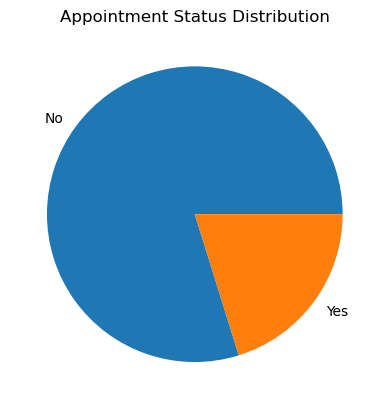

In [115]:
import matplotlib.pyplot as plt

df['No-show'].value_counts().plot(
    kind='pie',
)

plt.title("Appointment Status Distribution")
plt.ylabel("")
plt.show()

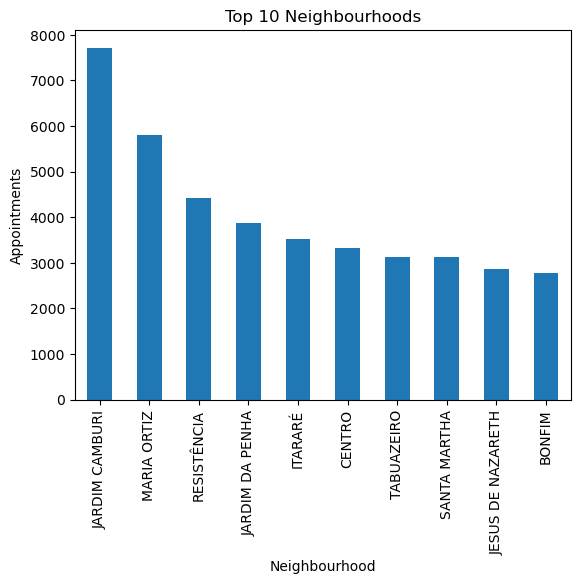

In [117]:
df['Neighbourhood'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Appointments")
plt.show()